# Konux Case Study – Complete Solution

This notebook provides a **complete solution** to the Konux Data Scientist case study.

It demonstrates:
- Preliminary signal analysis
- Train passage detection
- Feature extraction
- Train type classification (unsupervised)
- Relative train speed estimation (proxy)

**Sampling rate:** 2 kHz


## 1. Imports and Parameters

In [1]:
import os, glob
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

FS = 2000.0  # Sampling frequency (Hz)

## 2. Load Binary Acceleration Files

In [2]:
def read_trace(path):
    return np.fromfile(path, dtype=np.float32)

DATA_DIR = '/home/mamunds/job/pyspark/konux/data'  # change if needed
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.bin')))
print(f'Found {len(files)} files')

Found 20 files


## 3. Signal Preprocessing

In [3]:
def preprocess(x, fs=FS):
    x = x - np.median(x)
    sos = sig.butter(4, [5, 400], btype='bandpass', fs=fs, output='sos')
    return sig.sosfiltfilt(sos, x)

## 4. Train Passage Detection

In [4]:
def segment_passage(x, fs=FS, win_s=0.1):
    win = int(win_s * fs)
    rms = np.sqrt(sig.convolve(x**2, np.ones(win)/win, mode='same'))
    med = np.median(rms)
    mad = np.median(np.abs(rms - med)) + 1e-12
    thr = med + 6 * mad
    idx = np.where(rms > thr)[0]
    if len(idx) == 0:
        return x, rms, thr
    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends = np.r_[idx[splits], idx[-1]]
    k = np.argmax(ends - starts)
    s, e = starts[k], ends[k]
    pad = int(0.5 * fs)
    return x[max(0,s-pad):min(len(x), e+pad)], rms, thr

## 5. Example Visualization – Raw vs Filtered

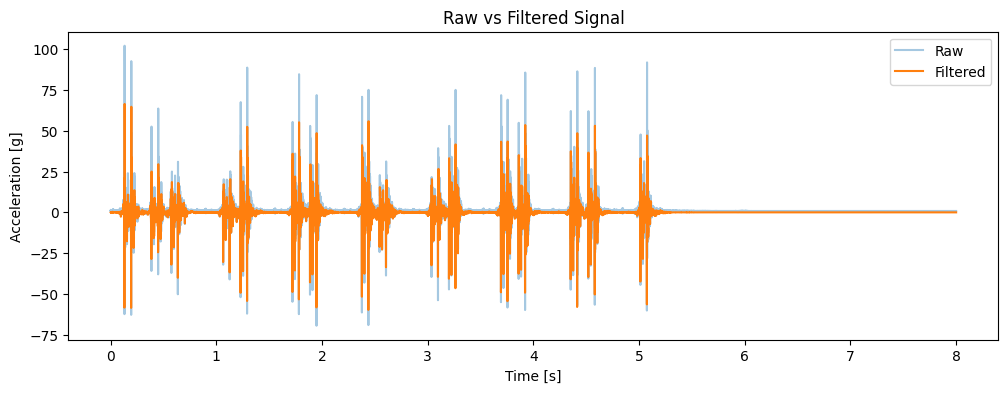

In [5]:
raw = read_trace(files[0])
filt = preprocess(raw)
t = np.arange(len(raw)) / FS

plt.figure(figsize=(12,4))
plt.plot(t, raw, alpha=0.4, label='Raw')
plt.plot(t, filt, label='Filtered')
plt.xlabel('Time [s]')
plt.ylabel('Acceleration [g]')
plt.title('Raw vs Filtered Signal')
plt.legend(); plt.show()

## 6. Example Visualization – Train Passage Detection

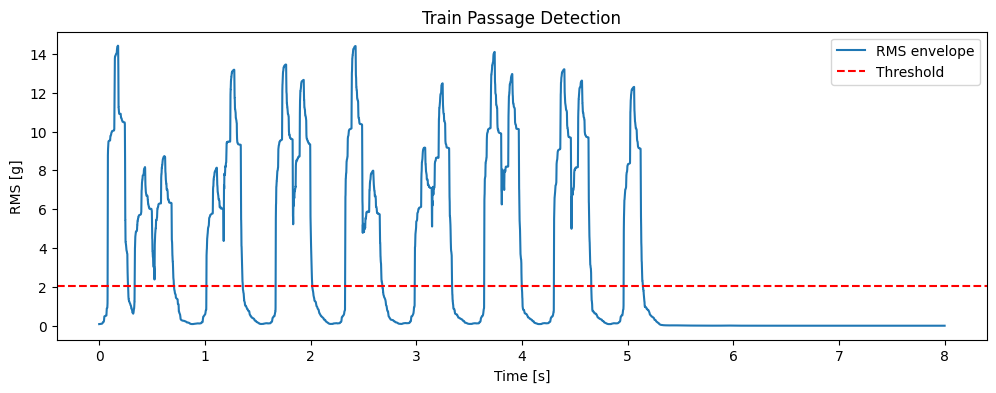

In [6]:
seg, rms, thr = segment_passage(filt)
t = np.arange(len(rms)) / FS

plt.figure(figsize=(12,4))
plt.plot(t, rms, label='RMS envelope')
plt.axhline(thr, color='r', linestyle='--', label='Threshold')
plt.xlabel('Time [s]')
plt.ylabel('RMS [g]')
plt.title('Train Passage Detection')
plt.legend(); plt.show()

## 7. Feature Extraction

In [7]:
def extract_features(x, fs=FS):
    f, Pxx = sig.welch(x, fs=fs, nperseg=min(4096, len(x)))
    env = np.abs(sig.hilbert(x))
    fe, Pe = sig.welch(env, fs=fs, nperseg=min(4096, len(env)))
    mask = (fe >= 1) & (fe <= 30)
    dom_env_freq = fe[mask][np.argmax(Pe[mask])]
    return {
        'duration_s': len(x)/fs,
        'rms': np.sqrt(np.mean(x**2)),
        'peak': np.max(np.abs(x)),
        'spec_centroid': np.sum(f*Pxx)/np.sum(Pxx),
        'env_dom_freq': dom_env_freq
    }

## 8. Process All Files

In [8]:
rows = []
for fpath in files:
    raw = read_trace(fpath)
    x = preprocess(raw)
    seg, _, _ = segment_passage(x)
    feats = extract_features(seg)
    feats['file'] = os.path.basename(fpath)
    rows.append(feats)

df = pd.DataFrame(rows)
df

,duration_s,rms,peak,spec_centroid,env_dom_freq,file
0,1.2080,5.959039,66.518336,182.411344,1.655629,20220507_131544_065205_001_channel1.bin
1,1.2255,7.653656,63.221110,217.507721,1.631987,20220507_131853_065205_001_channel1.bin
2,17.0000,1.242937,13.701409,184.384293,1.464844,20220509_091022_031264_001_channel1.bin
3,1.0205,1.780359,20.480243,199.359959,11.758942,20220509_094934_031264_001_channel1.bin
4,1.0960,0.968602,10.783772,153.385460,1.824818,20220509_095320_031157_001_channel1.bin
5,1.0565,1.105097,8.886638,180.563377,1.893043,20220509_100254_031157_001_channel1.bin
6,1.2470,1.740994,16.982437,207.960835,1.603849,20220509_104538_095913_001_channel1.bin
7,1.2395,1.713381,18.254353,201.071498,8.874546,20220509_105854_095913_001_channel1.bin
8,12.0000,0.199368,1.093623,205.062132,14.648438,20220511_110903_077531_001_channel1.bin
9,10.0000,0.568100,4.058151,231.045245,1.953125,20220511_120748_077531_001_channel1.bin


## 9. Train Type Classification (Clustering)

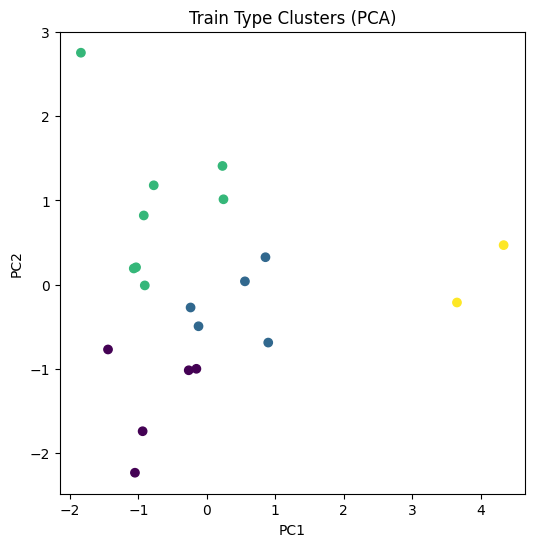

In [9]:
X = df.drop(columns=['file']).values
Xs = StandardScaler().fit_transform(X)
Z = PCA(n_components=2).fit_transform(Xs)

kmeans = KMeans(n_clusters=min(4, len(df)), random_state=0, n_init='auto')
df['cluster'] = kmeans.fit_predict(Z)

plt.figure(figsize=(6,6))
plt.scatter(Z[:,0], Z[:,1], c=df['cluster'])
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Train Type Clusters (PCA)')
plt.show()

## 10. Relative Train Speed Estimation

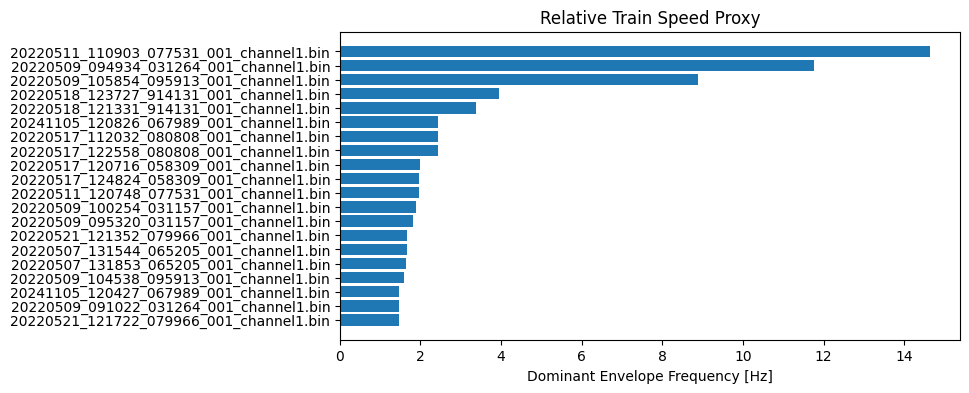

In [10]:
df_sorted = df.sort_values('env_dom_freq', ascending=False)

plt.figure(figsize=(8,4))
plt.barh(df_sorted['file'], df_sorted['env_dom_freq'])
plt.xlabel('Dominant Envelope Frequency [Hz]')
plt.title('Relative Train Speed Proxy')
plt.gca().invert_yaxis()
plt.show()

## 11. Save Results

In [ ]:
df.to_csv('train_analysis_results.csv', index=False)
print('Saved train_analysis_results.csv')